<a href="https://colab.research.google.com/github/shunnsoku7187/CA_m2/blob/main/%E4%B8%AD%E9%96%93%E5%AE%9F%E9%A8%93.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounting Google Drive...
Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/Research_Experiment
Using device: cuda
Preparing Dataset...


100%|██████████| 169M/169M [00:03<00:00, 42.3MB/s]


Loading existing results from '/content/drive/MyDrive/Research_Experiment/cifar100_difficulty_labels.json'...

     DIFFICULTY CLASSIFICATION RESULT     
Total Images: 10000
Easy       : 6894 (68.9%)
Hard       : 2091 (20.9%)
Impossible : 794 (7.9%)
Inverse    : 221 (2.2%)


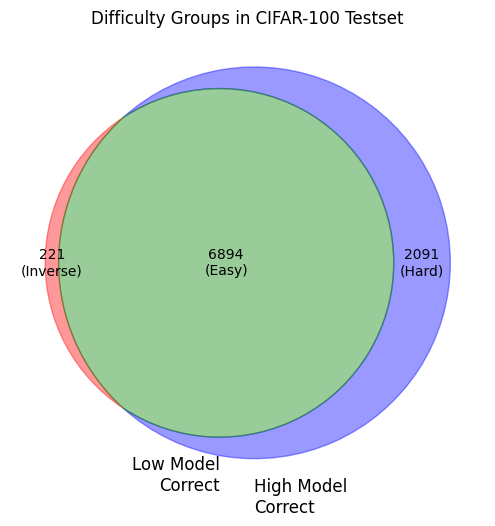

Graph saved as '/content/drive/MyDrive/Research_Experiment/difficulty_venn_diagram.png'


In [1]:
# 必要なライブラリのインストール
!pip install matplotlib-venn torchinfo transformers

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import os
from transformers import ViTForImageClassification
from google.colab import drive

# --- 1. Google Driveの設定 ---
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 保存先フォルダ（MyDrive直下の 'Research_Experiment' フォルダに保存します）
# 必要に応じて変更してください
SAVE_DIR = "/content/drive/MyDrive/Research_Experiment"
os.makedirs(SAVE_DIR, exist_ok=True)

# 保存ファイルパス
RESULT_JSON_PATH = os.path.join(SAVE_DIR, "cifar100_difficulty_labels.json")
GRAPH_IMAGE_PATH = os.path.join(SAVE_DIR, "difficulty_venn_diagram.png")

print(f"Results will be saved to: {SAVE_DIR}")

# --- 2. 設定 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

FORCE_INFERENCE = False  # Trueなら既存ファイルがあっても強制的に再推論

# --- 3. データセット準備 ---
print("Preparing Dataset...")

# Lowモデル用 (32x32, CIFAR標準正規化)
transform_low = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761])
])

# Highモデル用 (224x224, ImageNet標準正規化)
transform_high = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 生データ (画像ID管理用)
testset_raw = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=None)

# 修正: PIL画像をリストのまま受け取るための設定
def custom_collate(batch):
    images = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch])
    return images, labels

testloader = DataLoader(testset_raw, batch_size=50, shuffle=False, collate_fn=custom_collate)

# --- 4. 推論実行関数 ---
def run_inference():
    print("Loading Models...")

    # Low: MobileNetV2 x0.5
    try:
        low_model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_mobilenetv2_x0_5", pretrained=True)
    except:
        print("GitHub load failed. Using local fallback.")
        return []
    low_model.to(device).eval()

    # High: ViT-Base
    try:
        high_model = ViTForImageClassification.from_pretrained("Ahmed9275/Vit-Cifar100")
    except:
        print("HuggingFace load failed.")
        return []
    high_model.to(device).eval()

    results = []
    print("Starting Inference on CIFAR-100 Testset (10,000 images)...")

    # バッチ処理で推論
    global_idx = 0
    with torch.no_grad():
        for batch in tqdm(testloader):
            images, labels = batch # ここでのimagesはPIL形式のリスト
            labels = labels.to(device)

            # --- Lowモデル推論 ---
            # PIL -> Tensor変換
            batch_low = torch.stack([transform_low(img) for img in images]).to(device)
            out_low = low_model(batch_low)
            _, pred_low = torch.max(out_low, 1)

            # --- Highモデル推論 ---
            batch_high = torch.stack([transform_high(img) for img in images]).to(device)
            out_high = high_model(batch_high).logits
            _, pred_high = torch.max(out_high, 1)

            # 結果格納
            for i in range(len(labels)):
                label_val = labels[i].item()
                low_val = pred_low[i].item()
                high_val = pred_high[i].item()

                is_low_correct = (low_val == label_val)
                is_high_correct = (high_val == label_val)

                # 難易度カテゴリの決定
                if is_low_correct and is_high_correct:
                    cat = "Easy"
                elif not is_low_correct and is_high_correct:
                    cat = "Hard"
                elif not is_low_correct and not is_high_correct:
                    cat = "Impossible"
                else:
                    cat = "Inverse" # Lowのみ正解

                results.append({
                    "index": global_idx,
                    "label": label_val,
                    "low_pred": low_val,
                    "high_pred": high_val,
                    "low_correct": is_low_correct,
                    "high_correct": is_high_correct,
                    "category": cat
                })
                global_idx += 1

    return results

# --- 5. メイン処理 ---

if os.path.exists(RESULT_JSON_PATH) and not FORCE_INFERENCE:
    print(f"Loading existing results from '{RESULT_JSON_PATH}'...")
    with open(RESULT_JSON_PATH, 'r') as f:
        inference_data = json.load(f)
else:
    inference_data = run_inference()
    if inference_data:
        print(f"Saving results to '{RESULT_JSON_PATH}'...")
        with open(RESULT_JSON_PATH, 'w') as f:
            json.dump(inference_data, f, indent=2)

# --- 6. 結果の確認 (ベン図) ---
if inference_data:
    # 集計
    counts = {"Easy": 0, "Hard": 0, "Impossible": 0, "Inverse": 0}
    for item in inference_data:
        counts[item["category"]] += 1

    total = len(inference_data)
    print("\n" + "="*40)
    print("     DIFFICULTY CLASSIFICATION RESULT     ")
    print("="*40)
    print(f"Total Images: {total}")
    print(f"Easy       : {counts['Easy']} ({counts['Easy']/total*100:.1f}%)")
    print(f"Hard       : {counts['Hard']} ({counts['Hard']/total*100:.1f}%)")
    print(f"Impossible : {counts['Impossible']} ({counts['Impossible']/total*100:.1f}%)")
    print(f"Inverse    : {counts['Inverse']} ({counts['Inverse']/total*100:.1f}%)")

    # ベン図描画
    plt.figure(figsize=(8, 6))
    v = venn2(subsets=(counts['Inverse'], counts['Hard'], counts['Easy']),
              set_labels=('Low Model\nCorrect', 'High Model\nCorrect'))

    # 色設定
    try:
        if v.get_patch_by_id('10'): v.get_patch_by_id('10').set_color('red') # Inverse
        if v.get_patch_by_id('01'): v.get_patch_by_id('01').set_color('blue') # Hard
        if v.get_patch_by_id('11'): v.get_patch_by_id('11').set_color('green') # Easy

        # ラベル
        if v.get_label_by_id('10'): v.get_label_by_id('10').set_text(f"{counts['Inverse']}\n(Inverse)")
        if v.get_label_by_id('01'): v.get_label_by_id('01').set_text(f"{counts['Hard']}\n(Hard)")
        if v.get_label_by_id('11'): v.get_label_by_id('11').set_text(f"{counts['Easy']}\n(Easy)")
    except:
        pass

    plt.title("Difficulty Groups in CIFAR-100 Testset")
    plt.savefig(GRAPH_IMAGE_PATH) # Driveに保存
    plt.show()
    print(f"Graph saved as '{GRAPH_IMAGE_PATH}'")

Loading data from: /content/drive/MyDrive/Research_Experiment/cifar100_difficulty_labels.json
Loaded 10000 samples.

=== Classification Result ===
Total: 10000
Easy: 6894 (68.9%)
Hard: 2091 (20.9%)
Impossible: 794 (7.9%)
Inverse: 221 (2.2%)

Venn diagram saved to: /content/drive/MyDrive/Research_Experiment/step2_difficulty_venn.png


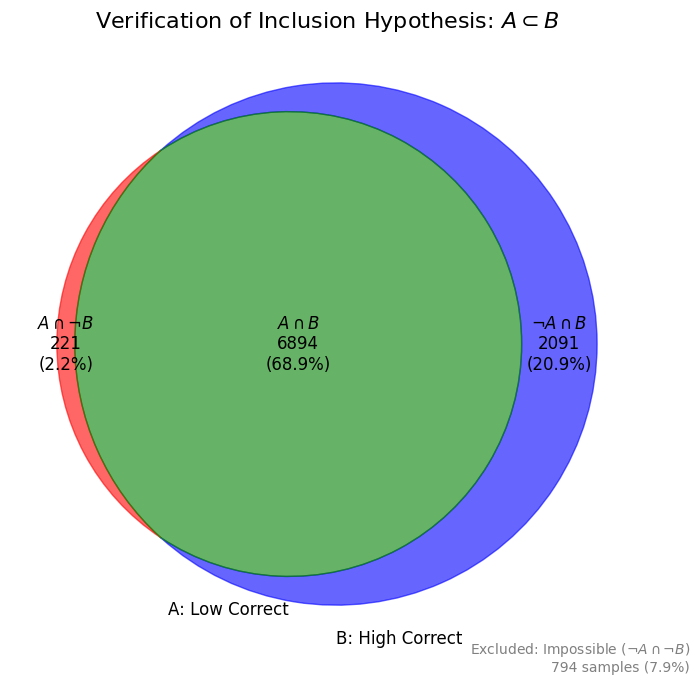

In [2]:
# 必要なライブラリのインストール
!pip install matplotlib-venn

import json
import os
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from google.colab import drive

# --- 1. Google Driveの設定 ---
# 前のステップと同じパスを使用します
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Research_Experiment"
JSON_PATH = os.path.join(BASE_DIR, "cifar100_difficulty_labels.json")
OUTPUT_IMAGE_PATH = os.path.join(BASE_DIR, "step2_difficulty_venn.png")

# --- 2. JSONデータの読み込み ---
print(f"Loading data from: {JSON_PATH}")

if not os.path.exists(JSON_PATH):
    raise FileNotFoundError(f"File not found: {JSON_PATH}. Please run Step 1 first.")

with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print(f"Loaded {len(data)} samples.")

# --- 3. データの集計 ---
# カテゴリごとのカウント
counts = {
    "Easy": 0,       # A ∩ B (Low○ High○)
    "Hard": 0,       # ¬A ∩ B (Low× High○)
    "Impossible": 0, # ¬A ∩ ¬B (Low× High×) -> 今回は図示しない
    "Inverse": 0     # A ∩ ¬B (Low○ High×) -> 少ないはず
}

for item in data:
    cat = item.get("category", "")
    if cat in counts:
        counts[cat] += 1

total = len(data)
# ベン図に表示するサンプルの総数（Impossibleを除く）
venn_total = counts['Easy'] + counts['Hard'] + counts['Inverse']

print("\n=== Classification Result ===")
print(f"Total: {total}")
for k, v in counts.items():
    print(f"{k}: {v} ({v/total*100:.1f}%)")

# --- 4. ベン図の作成 ---
plt.figure(figsize=(10, 8))

# venn2の引数: subsets = (Ab, aB, AB)
# Ab: Group A only (Low only) -> Inverse -> A ∩ ¬B
# aB: Group B only (High only) -> Hard -> ¬A ∩ B
# AB: Both (Intersection) -> Easy -> A ∩ B
subset_sizes = (counts['Inverse'], counts['Hard'], counts['Easy'])
v = venn2(subsets=subset_sizes, set_labels=('A: Low Correct', 'B: High Correct'))

# 色とラベルのカスタマイズ
try:
    # --------------------------------------------------------------------------
    # ★ラベルの表示位置調整 & 論理式による記述
    # --------------------------------------------------------------------------

    # 1. Inverse (A ∩ ¬B) -> 赤 (例外・ノイズ)
    if v.get_patch_by_id('10'):
        v.get_patch_by_id('10').set_color('red')
        v.get_patch_by_id('10').set_alpha(0.6)

        lbl = v.get_label_by_id('10')
        # 論理式で表記
        lbl.set_text(f"$A \\cap \\neg B$\n{counts['Inverse']}\n({counts['Inverse']/total*100:.1f}%)")
        lbl.set_fontsize(12)

    # 2. Hard (¬A ∩ B) -> 青 (Highの価値)
    if v.get_patch_by_id('01'):
        v.get_patch_by_id('01').set_color('blue')
        v.get_patch_by_id('01').set_alpha(0.6)

        lbl = v.get_label_by_id('01')
        # 論理式で表記
        lbl.set_text(f"$\\neg A \\cap B$\n{counts['Hard']}\n({counts['Hard']/total*100:.1f}%)")
        lbl.set_fontsize(12)

    # 3. Easy (A ∩ B) -> 緑 (包含部分)
    if v.get_patch_by_id('11'):
        v.get_patch_by_id('11').set_color('green')
        v.get_patch_by_id('11').set_alpha(0.6)

        lbl = v.get_label_by_id('11')
        # 論理式で表記
        lbl.set_text(f"$A \\cap B$\n{counts['Easy']}\n({counts['Easy']/total*100:.1f}%)")
        lbl.set_fontsize(12)

except Exception as e:
    print(f"Error customizing venn diagram: {e}")

# タイトル
plt.title(r"Verification of Inclusion Hypothesis: $A \subset B$", fontsize=16)

# 補足情報の表示（Impossibleは枠外に小さく記載）
plt.text(0.8, -0.7,
         f"Excluded: Impossible ($\\neg A \\cap \\neg B$)\n{counts['Impossible']} samples ({counts['Impossible']/total*100:.1f}%)",
         fontsize=10, ha='right', color='gray')

# 保存と表示
plt.savefig(OUTPUT_IMAGE_PATH)
print(f"\nVenn diagram saved to: {OUTPUT_IMAGE_PATH}")
plt.show()

In [3]:
# 必要なライブラリのインストール
!pip install scipy

import json
import os
import numpy as np
from scipy.stats import chi2_contingency, norm
from google.colab import drive

# --- 1. Google Driveの設定 ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Research_Experiment"
JSON_PATH = os.path.join(BASE_DIR, "cifar100_difficulty_labels.json")

# --- 2. JSONデータの読み込み ---
print(f"Loading data from: {JSON_PATH}")

if not os.path.exists(JSON_PATH):
    raise FileNotFoundError(f"File not found: {JSON_PATH}. Please run Step 1 first.")

with open(JSON_PATH, 'r') as f:
    data = json.load(f)

total = len(data)
print(f"Loaded {total} samples.\n")

# --- 3. データの集計 ---
counts = {
    "Easy": 0,       # Low○ High○
    "Hard": 0,       # Low× High○
    "Impossible": 0, # Low× High×
    "Inverse": 0     # Low○ High×
}

for item in data:
    cat = item.get("category", "")
    if cat in counts:
        counts[cat] += 1

# 各カテゴリの割合
r_easy = counts['Easy'] / total
r_hard = counts['Hard'] / total
r_imp = counts['Impossible'] / total
r_inv = counts['Inverse'] / total

# Lowモデル全体の正解率 P(Low)
n_low_correct = counts['Easy'] + counts['Inverse']
p_low = n_low_correct / total

# Highモデル全体の正解率 P(High)
n_high_correct = counts['Easy'] + counts['Hard']
p_high = n_high_correct / total


# --- 4. 統計的検定 1: 独立性のカイ二乗検定 ---
# 観測されたクロス集計表 (Observed)
#           High〇          High×
# Low〇     Easy (Both)     Inverse (LowOnly)
# Low×     Hard (HighOnly) Impossible (Neither)
observed = np.array([
    [counts['Easy'], counts['Inverse']],
    [counts['Hard'], counts['Impossible']]
])

# カイ二乗検定
chi2, p_chi2, dof, expected = chi2_contingency(observed)


# --- 5. 統計的検定 2: Z検定 (正規近似) ---
# 帰無仮説: 「Inverseの発生率は、LowとHighが独立（ランダム）だった場合の期待値に従う」
# 期待されるInverse率 P_exp = P(Low) * P(not High)
p_exp_inverse = p_low * (1.0 - p_high)
n_exp_inverse = p_exp_inverse * total

# 観測されたInverse率 P_obs
p_obs_inverse = r_inv

# Zスコアの計算
# 標準誤差 SE = sqrt( p(1-p) / n )
se = np.sqrt(p_exp_inverse * (1.0 - p_exp_inverse) / total)
z_score = (p_obs_inverse - p_exp_inverse) / se

# p値 (片側検定: 観測値が期待値より低い確率)
p_val_z = norm.cdf(z_score)


# --- 6. レポート出力 ---
print("="*60)
print("             STATISTICAL VALIDATION REPORT             ")
print("="*60)

print("[1] Basic Statistics")
print(f"  Total Images       : {total}")
print(f"  Low Model Accuracy : {p_low*100:.2f}%")
print(f"  High Model Accuracy: {p_high*100:.2f}%")
print("-" * 60)
print(f"  Easy (A ∩ B)       : {counts['Easy']:>5} ({r_easy*100:.2f}%)")
print(f"  Hard (¬A ∩ B)      : {counts['Hard']:>5} ({r_hard*100:.2f}%)")
print(f"  Inverse (A ∩ ¬B)   : {counts['Inverse']:>5} ({r_inv*100:.2f}%)  <-- Critical Metric")
print(f"  Impossible         : {counts['Impossible']:>5} ({r_imp*100:.2f}%)")
print("="*60)

print("\n[2] Independence Test (Chi-Squared)")
print("  Null Hypothesis (H0): Low and High model predictions are independent.")
print(f"  Chi2 Value : {chi2:.4f}")
print(f"  p-value    : {p_chi2:.4e}")
if p_chi2 < 0.01:
    print("  >> RESULT: Significant (Rejected H0). Models are correlated.")
else:
    print("  >> RESULT: Not Significant.")
print("="*60)

print("\n[3] Inclusion Hypothesis Test (Z-Test)")
print("  Hypothesis: 'Inverse' cases are significantly fewer than random chance.")
print("  (Proof of Inclusion Relationship: Easy ⊂ Hard)")
print("-" * 60)
print(f"  Expected Inverse (if Random) : {n_exp_inverse:.1f} images ({p_exp_inverse*100:.2f}%)")
print(f"  Observed Inverse (Actual)    : {counts['Inverse']} images ({p_obs_inverse*100:.2f}%)")
print(f"  Difference                   : {counts['Inverse'] - n_exp_inverse:.1f} images")
print("-" * 60)
print(f"  Z-Score : {z_score:.4f} σ")
print(f"  p-value : {p_val_z:.4e}")

if z_score < -3.0:
    print("  >> CONCLUSION: HIGHLY SIGNIFICANT.")
    print(f"     The occurrence of Inverse samples is {abs(z_score):.1f} sigma lower than chance.")
    print("     This statistically proves the existence of difficulty hierarchy.")
else:
    print("  >> CONCLUSION: Not significant enough to prove strong inclusion.")
print("="*60)

Loading data from: /content/drive/MyDrive/Research_Experiment/cifar100_difficulty_labels.json
Loaded 10000 samples.

             STATISTICAL VALIDATION REPORT             
[1] Basic Statistics
  Total Images       : 10000
  Low Model Accuracy : 71.15%
  High Model Accuracy: 89.85%
------------------------------------------------------------
  Easy (A ∩ B)       :  6894 (68.94%)
  Hard (¬A ∩ B)      :  2091 (20.91%)
  Inverse (A ∩ ¬B)   :   221 (2.21%)  <-- Critical Metric
  Impossible         :   794 (7.94%)

[2] Independence Test (Chi-Squared)
  Null Hypothesis (H0): Low and High model predictions are independent.
  Chi2 Value : 1339.0680
  p-value    : 3.6584e-293
  >> RESULT: Significant (Rejected H0). Models are correlated.

[3] Inclusion Hypothesis Test (Z-Test)
  Hypothesis: 'Inverse' cases are significantly fewer than random chance.
  (Proof of Inclusion Relationship: Easy ⊂ Hard)
------------------------------------------------------------
  Expected Inverse (if Random) : 722.

In [4]:
# 必要なライブラリのインストール
!pip install torchinfo transformers matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary
from tqdm import tqdm
import os
from google.colab import drive

# --- 1. Google Driveの設定 ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Research_Experiment"
os.makedirs(BASE_DIR, exist_ok=True)

# 保存するモデルのパス
MODEL_PATH = os.path.join(BASE_DIR, "tiny_router_cifar100_cls.pth")

# 再学習を強制するか（Trueなら保存済みファイルがあっても上書き学習）
FORCE_RETRAIN = False

# --- 2. 設定 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ハイパーパラメータ
BATCH_SIZE = 128
EPOCHS = 20        # 十分な自信を持たせるため少し長めに
LEARNING_RATE = 0.001

# --- 3. Tinyモデル定義 (Router) ---
# 役割: 入力画像の特徴を「ざっくり」捉え、確信度を算出する
class TinyRouter(nn.Module):
    def __init__(self):
        super(TinyRouter, self).__init__()
        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: 8x8 -> 4x4
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        # Classifier (100クラス分類)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 100)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

tiny_model = TinyRouter().to(device)

# --- 4. コスト（FLOPs）の確認 ---
print("\n[Tiny Router Specification]")
model_stats = summary(tiny_model, input_size=(1, 3, 32, 32), verbose=0)
print(f"Params: {model_stats.total_params / 1e6:.4f} M")
print(f"FLOPs : {model_stats.total_mult_adds / 1e9:.6f} GFLOPs")
# 比較用: MobileNetV2は約0.3 GFLOPsなので、それより遥かに軽いことを確認


# --- 5. データセット準備 ---
print("\nPreparing Data...")

# Data Augmentation (学習を安定させ、自信の精度を高めるため)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

# テスト用（検証用）
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)


# --- 6. 学習処理 ---
def train_model():
    print("\n" + "="*40)
    print(f"     START TRAINING ({EPOCHS} Epochs)     ")
    print("="*40)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(tiny_model.parameters(), lr=LEARNING_RATE)
    # 学習率減衰
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)

    tiny_model.train()

    for epoch in range(EPOCHS):
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(trainloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = tiny_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_postfix(loss=loss.item(), acc=100*correct/total)

        scheduler.step()
        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100 * correct / total
        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.2f}%")

    # 保存
    print(f"\nSaving model to '{MODEL_PATH}'...")
    torch.save(tiny_model.state_dict(), MODEL_PATH)
    print("Training Completed & Saved.")

# --- 7. メイン実行部 ---
if os.path.exists(MODEL_PATH) and not FORCE_RETRAIN:
    print(f"\n[INFO] Found saved model: '{MODEL_PATH}'")
    print("Loading weights... (Skipping Training)")
    tiny_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
else:
    train_model()

# --- 8. 簡易評価（Accuracy確認） ---
print("\n[Evaluation on Test Set]")
tiny_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in tqdm(testloader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = tiny_model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Tiny Router Accuracy: {100 * correct / total:.2f}%")
print("(This accuracy is not the final goal. The 'Confidence' distribution matters more.)")

Using device: cuda

[Tiny Router Specification]
Params: 0.3447 M
FLOPs : 0.008304 GFLOPs

Preparing Data...

[INFO] Found saved model: '/content/drive/MyDrive/Research_Experiment/tiny_router_cifar100_cls.pth'
Loading weights... (Skipping Training)

[Evaluation on Test Set]


100%|██████████| 100/100 [00:05<00:00, 17.86it/s]

Tiny Router Accuracy: 49.33%
(This accuracy is not the final goal. The 'Confidence' distribution matters more.)


In [5]:
# 必要なライブラリのインストール
!pip install torchinfo transformers

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
from google.colab import drive

# --- 1. Google Driveの設定 ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Research_Experiment"
# 入力ファイル: ステップ1で作った難易度ラベル
INPUT_JSON_PATH = os.path.join(BASE_DIR, "cifar100_difficulty_labels.json")
# 出力ファイル: 確信度を追記したデータ
OUTPUT_JSON_PATH = os.path.join(BASE_DIR, "cifar100_simulation_data.json")
# モデルファイル: ステップ4で作ったTinyモデル
MODEL_PATH = os.path.join(BASE_DIR, "tiny_router_cifar100_cls.pth")

# --- 2. 設定 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 3. Tinyモデル定義 (学習時と同じ構造) ---
class TinyRouter(nn.Module):
    def __init__(self):
        super(TinyRouter, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 100)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# モデルのロード
print(f"Loading Tiny Router from '{MODEL_PATH}'...")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("Model file not found. Please run Step 4 first.")

tiny_model = TinyRouter().to(device)
tiny_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
tiny_model.eval()

# --- 4. データセット準備 ---
# Tinyモデル学習時と同じ正規化を使用
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

# 画像データ取得用 (CIFAR-100 Test)
testset_raw = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=None)


# --- 5. 推論とデータ統合 ---
print(f"Loading Difficulty Labels from '{INPUT_JSON_PATH}'...")
if not os.path.exists(INPUT_JSON_PATH):
    raise FileNotFoundError("Difficulty labels not found. Please run Step 1 first.")

with open(INPUT_JSON_PATH, 'r') as f:
    data_list = json.load(f)

print(f"Processing {len(data_list)} samples...")
print("Calculating Confidence Scores...")

updated_data = []

with torch.no_grad():
    for item in tqdm(data_list):
        idx = item['index']
        img_raw, _ = testset_raw[idx]

        # Tinyモデルで推論
        img_tensor = transform_test(img_raw).unsqueeze(0).to(device)
        outputs = tiny_model(img_tensor)

        # Softmaxで確率に変換し、最大値（確信度）を取得
        probs = torch.nn.functional.softmax(outputs, dim=1)
        conf, pred_cls = torch.max(probs, 1)

        # データを更新（確信度を追加）
        item['tiny_conf'] = conf.item()
        item['tiny_pred'] = pred_cls.item() # 参考: Tinyモデルの予測クラス

        updated_data.append(item)

# --- 6. 保存 ---
print(f"\nSaving simulation data to '{OUTPUT_JSON_PATH}'...")
with open(OUTPUT_JSON_PATH, 'w') as f:
    json.dump(updated_data, f, indent=2)

print("Done. Ready for Split Cascade Simulation (Step 6).")

Using device: cuda
Loading Tiny Router from '/content/drive/MyDrive/Research_Experiment/tiny_router_cifar100_cls.pth'...
Loading Difficulty Labels from '/content/drive/MyDrive/Research_Experiment/cifar100_difficulty_labels.json'...
Processing 10000 samples...
Calculating Confidence Scores...


100%|██████████| 10000/10000 [00:23<00:00, 417.63it/s]



Saving simulation data to '/content/drive/MyDrive/Research_Experiment/cifar100_simulation_data.json'...
Done. Ready for Split Cascade Simulation (Step 6).


Loading simulation data from '/content/drive/MyDrive/Research_Experiment/cifar100_simulation_data.json'...
Loaded 10000 samples.

Generating Confidence Distribution Histogram...


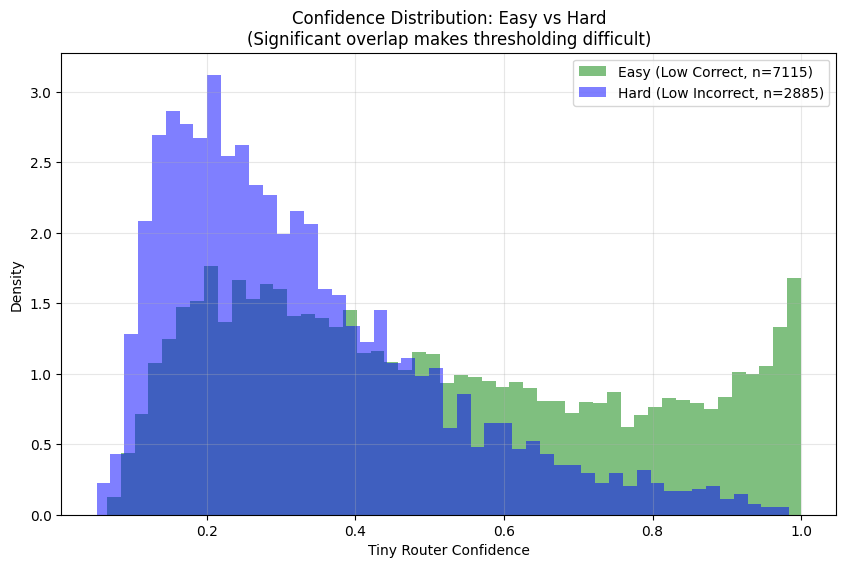

Histogram saved to '/content/drive/MyDrive/Research_Experiment/step6_confidence_overlap.png'


     START SIMULATION (No Inference)     


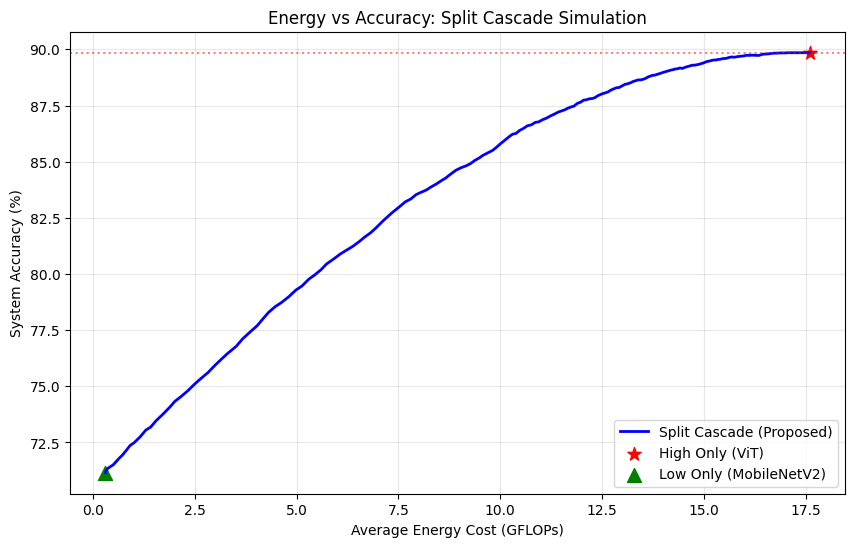

Graph saved to '/content/drive/MyDrive/Research_Experiment/step6_split_cascade_result.png'

[Supplementary Note: Impact of Threshold]
閾値(Threshold)を上げると -> Low判定が厳しくなる -> Highモデル利用率が増加
結果として：
  1. 平均コスト(GFLOPs)が増加（グラフの横軸が右へ移動）
  2. システム精度が向上（Highモデルの性能に近づく）
-----------------------------------------------------------------
Threshold  | To Low (%)   | To High (%)  | Cost (GFLOPs)   | Accuracy (%)
-----------------------------------------------------------------
0.0        | 100.0        | 0.0          | 0.306           | 71.2        
0.2        | 82.7         | 17.3         | 3.299           | 76.5        
0.4        | 48.8         | 51.2         | 9.158           | 84.8        
0.6        | 28.3         | 71.7         | 12.704          | 88.2        
0.8        | 14.8         | 85.2         | 15.038          | 89.4        
1.0        | 0.0          | 100.0        | 17.605          | 89.8        
-----------------------------------------------------------------

     OPTIMAL OPERATING PO

In [6]:
# 必要なライブラリのインストール
!pip install matplotlib numpy

import json
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# --- 1. Google Driveの設定 ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Research_Experiment"
INPUT_JSON_PATH = os.path.join(BASE_DIR, "cifar100_simulation_data.json")

# --- 2. 設定 ---
# コスト計算用の固定値 (GFLOPs)
# ※前のステップでの計測値を入力してください。ここでは概算値を使用します。
FLOPS_LOW  = 0.301 # MobileNetV2
FLOPS_HIGH = 17.6  # ViT-Base
FLOPS_TINY = 0.005 # Tiny Router (仮)

# --- 3. データの読み込み ---
print(f"Loading simulation data from '{INPUT_JSON_PATH}'...")

if not os.path.exists(INPUT_JSON_PATH):
    raise FileNotFoundError(f"File not found: {INPUT_JSON_PATH}. Please run Step 5 first.")

with open(INPUT_JSON_PATH, 'r') as f:
    data_list = json.load(f)

total_n = len(data_list)
print(f"Loaded {total_n} samples.")


# --- 3.5 確信度分布のヒストグラム (分布の重なりを確認) ---
print("\nGenerating Confidence Distribution Histogram...")
# Easy: Lowモデルで正解できる画像 (categoryがEasyまたはInverse)
# Hard: Lowモデルで正解できない画像 (categoryがHardまたはImpossible)
# data_listには 'low_correct' フラグがあるのでそれを利用
easy_confs = [d['tiny_conf'] for d in data_list if d['low_correct']]
hard_confs = [d['tiny_conf'] for d in data_list if not d['low_correct']]

plt.figure(figsize=(10, 6))
# 密度表示(density=True)にして分布形状の重なりを比較
# alphaを設定して透過させることで重なり部分を見やすくする
plt.hist(easy_confs, bins=50, alpha=0.5, label=f'Easy (Low Correct, n={len(easy_confs)})', color='green', density=True)
plt.hist(hard_confs, bins=50, alpha=0.5, label=f'Hard (Low Incorrect, n={len(hard_confs)})', color='blue', density=True)

plt.xlabel('Tiny Router Confidence')
plt.ylabel('Density')
plt.title('Confidence Distribution: Easy vs Hard\n(Significant overlap makes thresholding difficult)')
plt.legend()
plt.grid(True, alpha=0.3)

HIST_OUTPUT_PATH = os.path.join(BASE_DIR, "step6_confidence_overlap.png")
plt.savefig(HIST_OUTPUT_PATH)
plt.show()
print(f"Histogram saved to '{HIST_OUTPUT_PATH}'\n")


# --- 4. シミュレーション ---
print("\n" + "="*50)
print("     START SIMULATION (No Inference)     ")
print("="*50)

# 確信度でソート（閾値処理を効率化するため）
# Tinyモデルの確信度が高い順に並べる
data_list.sort(key=lambda x: x["tiny_conf"], reverse=True)

results = []
# 閾値を 0.00 から 1.00 まで細かく振る
thresholds = np.linspace(0, 1.0, 201)

for th in thresholds:
    # 閾値判定ロジック:
    # Conf >= th -> Lowへ (コスト: Tiny + Low)
    # Conf < th  -> Highへ (コスト: Tiny + High)

    # リストを分割（ソート済みなのでスライスでも可能だが、わかりやすくリスト内包表記で記述）
    to_low = [d for d in data_list if d["tiny_conf"] >= th]
    to_high = [d for d in data_list if d["tiny_conf"] < th]

    n_low = len(to_low)
    n_high = len(to_high)

    # ① 平均コスト計算 (GFLOPs)
    # 全画像でTinyは実行済み + 分岐先のコスト
    total_cost = (total_n * FLOPS_TINY) + (n_low * FLOPS_LOW) + (n_high * FLOPS_HIGH)
    avg_cost = total_cost / total_n

    # ② システム精度計算
    # Lowへ行った画像: Lowで正解ならOK (is_easyがTrueなら正解)
    # Highへ行った画像: Highで正解ならOK (high_correctがTrueなら正解)

    # ここでの「Lowで正解」は「categoryがEasyまたはInverse」であることを意味する
    # data_listには 'category' フィールドがあるはずだが、念のため is_low_correct を使用
    correct_low = sum(1 for d in to_low if d["low_correct"])
    correct_high = sum(1 for d in to_high if d["high_correct"])

    accuracy = 100 * (correct_low + correct_high) / total_n

    # Easyのカバレッジ（Easy画像のうち、どれだけLowで処理できたか）
    # ここでのEasyは「Lowで正解できる画像」全体を指す
    total_easy = sum(1 for d in data_list if d["low_correct"])
    easy_processed_by_low = sum(1 for d in to_low if d["low_correct"])
    easy_coverage = 100 * easy_processed_by_low / total_easy if total_easy > 0 else 0

    results.append({
        "th": th,
        "cost": avg_cost,
        "acc": accuracy,
        "ratio_low": n_low / total_n,
        "easy_cov": easy_coverage
    })

# --- 5. 結果の可視化 ---
costs = [r["cost"] for r in results]
accs = [r["acc"] for r in results]

# 基準点 (High単独)
acc_high_only = sum(1 for d in data_list if d["high_correct"]) / total_n * 100
cost_high_only = FLOPS_HIGH

# 基準点 (Low単独)
acc_low_only = sum(1 for d in data_list if d["low_correct"]) / total_n * 100
cost_low_only = FLOPS_LOW

plt.figure(figsize=(10, 6))

# 提案手法の曲線
plt.plot(costs, accs, label='Split Cascade (Proposed)', color='blue', linewidth=2)

# 基準点のプロット
plt.scatter([cost_high_only], [acc_high_only], color='red', label='High Only (ViT)', s=100, marker='*')
plt.scatter([cost_low_only], [acc_low_only], color='green', label='Low Only (MobileNetV2)', s=100, marker='^')

# High精度の基準線
plt.axhline(y=acc_high_only, color='red', linestyle=':', alpha=0.5)

plt.xlabel('Average Energy Cost (GFLOPs)')
plt.ylabel('System Accuracy (%)')
plt.title('Energy vs Accuracy: Split Cascade Simulation')
plt.grid(True, alpha=0.3)
plt.legend()

# グラフ保存
OUTPUT_GRAPH_PATH = os.path.join(BASE_DIR, "step6_split_cascade_result.png")
plt.savefig(OUTPUT_GRAPH_PATH)
plt.show()
print(f"Graph saved to '{OUTPUT_GRAPH_PATH}'")

# --- 補足: 閾値とコストの関係性についてのログ出力 ---
print("\n[Supplementary Note: Impact of Threshold]")
print("閾値(Threshold)を上げると -> Low判定が厳しくなる -> Highモデル利用率が増加")
print("結果として：")
print("  1. 平均コスト(GFLOPs)が増加（グラフの横軸が右へ移動）")
print("  2. システム精度が向上（Highモデルの性能に近づく）")
print("-" * 65)
print(f"{'Threshold':<10} | {'To Low (%)':<12} | {'To High (%)':<12} | {'Cost (GFLOPs)':<15} | {'Accuracy (%)':<12}")
print("-" * 65)
# 傾向をつかむために0.1刻みでピックアップ表示
for t_check in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    # 近似する結果を取得
    res = min(results, key=lambda x: abs(x['th'] - t_check))
    print(f"{res['th']:<10.1f} | {res['ratio_low']*100:<12.1f} | {(1-res['ratio_low'])*100:<12.1f} | {res['cost']:<15.3f} | {res['acc']:<12.1f}")
print("-" * 65)


# --- 6. 最適点の探索と詳細レポート ---
# 「Highモデルの精度から劣化1%以内」で「最もエネルギーが低い点」を探す
target_acc = acc_high_only - 1.0
optimal_point = None

# コストが低い順に探索
for res in sorted(results, key=lambda x: x["cost"]):
    if res["acc"] >= target_acc:
        optimal_point = res
        break

print("\n" + "="*50)
print("     OPTIMAL OPERATING POINT REPORT     ")
print("="*50)

if optimal_point:
    th = optimal_point["th"]

    # 割り振り詳細を計算
    # True Easy (Low Correct) vs True Hard (Low Incorrect)
    # 振り分け先: Low (Conf >= th) vs High (Conf < th)

    n_easy_total = sum(1 for d in data_list if d["low_correct"])
    n_hard_total = sum(1 for d in data_list if not d["low_correct"])

    n_easy_to_low = sum(1 for d in data_list if d["low_correct"] and d["tiny_conf"] >= th)
    n_easy_to_high = sum(1 for d in data_list if d["low_correct"] and d["tiny_conf"] < th)

    n_hard_to_low = sum(1 for d in data_list if not d["low_correct"] and d["tiny_conf"] >= th)
    n_hard_to_high = sum(1 for d in data_list if not d["low_correct"] and d["tiny_conf"] < th)

    print(f"Target Accuracy: > {target_acc:.1f}% (High - 1.0%)")
    print(f"----------------------------------------")
    print(f"Optimal Threshold: {optimal_point['th']:.2f}")
    print(f"System Accuracy  : {optimal_point['acc']:.1f}% (High Only: {acc_high_only:.1f}%)")
    print(f"Average Energy   : {optimal_point['cost']:.3f} GFLOPs")
    print(f"Energy Reduction : {100 * (1 - optimal_point['cost']/cost_high_only):.1f}% vs High Only")
    print(f"----------------------------------------")
    print(f"Routing Details (Analysis of 'Collateral Damage'):")
    print(f"\n[True Hard Samples] (Total: {n_hard_total})")
    print(f"  - Successfully sent to High: {n_hard_to_high:>5} ({n_hard_to_high/n_hard_total*100:.1f}%) -> Accuracy Maintained")
    print(f"  - Mistakenly sent to Low   : {n_hard_to_low:>5} ({n_hard_to_low/n_hard_total*100:.1f}%) -> Accuracy Loss")

    print(f"\n[True Easy Samples] (Total: {n_easy_total})")
    print(f"  - Successfully sent to Low : {n_easy_to_low:>5} ({n_easy_to_low/n_easy_total*100:.1f}%) -> Energy Saved")
    print(f"  - Unnecessarily to High    : {n_easy_to_high:>5} ({n_easy_to_high/n_easy_total*100:.1f}%) -> Energy Wasted (Collateral Damage)")

    # 考察メッセージ
    print("\n[Conclusion from Log]")
    print(f"To capture {n_hard_to_high/n_hard_total*100:.1f}% of Hard samples,")
    print(f"we had to send {n_easy_to_high/n_easy_total*100:.1f}% of Easy samples to the High model as well.")
    print("This 'Collateral Damage' limits the energy reduction.")
else:
    print("Target accuracy could not be achieved.")
    # 参考：最高精度が出るポイント
    best_acc_point = max(results, key=lambda x: x["acc"])
    print(f"(Best achievable accuracy was {best_acc_point['acc']:.1f}% at threshold {best_acc_point['th']:.2f})")

print("="*50)